# STEP 1 · 数据探索
查看数据的规模与形状——多少车、多少 GPS 点、覆盖范围、采样/速度分布、充电站规模。

**Example**(广州 2019-10-14)：约 **3.34 万辆**网约车、**1,320 万**条 GPS 点；现有公共充电站 **3,191 个**(快充枪 4.3 万 + 慢充枪 0.8 万)。

In [36]:
import os, sys, time, importlib
sys.path.insert(0, os.getcwd())          # STEP_0 已在本目录生成 cso_config.py / cso_engine.py
# 数据默认在“本 Code 目录的上一级”(项目根, 含 parquet 与 station csv)。如不同请改下一行或设环境变量 CSO_DATA：
# os.environ['CSO_DATA'] = r'D:/Desktop/香港大学/20260521 根据网约车轨迹优化充电站'
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
    'font.sans-serif': ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Arial Unicode MS', 'DejaVu Sans'],
    'axes.unicode_minus': False,
})
import cso_config as C, cso_engine as E
importlib.reload(C); importlib.reload(E)
print('当前城市:', C.city()['label'], '| 数据:', C.city()['raw_path'].name, '| 缓存:', C.CACHE)

当前城市: 广州 Guangzhou | 数据: Taxi_2019_10_14_admin_4401.parquet | 缓存: D:\Desktop\香港大学\20260521 根据网约车轨迹优化充电站\Code\_cache


## 1.1 读取轨迹(惰性扫描)并统计规模
直接对 parquet 惰性扫描；先看字段，再统计行数与车辆数。

In [37]:
cfg = C.city(); b = cfg['bbox']
lf = E.pl.scan_parquet(str(cfg['raw_path']))
print('字段:', lf.collect_schema().names())
rows = lf.select(E.pl.len()).collect().item()
nveh = lf.select(E.pl.col('vehicle_id').n_unique()).collect().item()
print('GPS 记录数 = {:,}'.format(rows))
print('车辆数(去重) = {:,}'.format(nveh))

字段: ['vehicle_id', 'lon', 'lat', 'speed_kmh', 'heading', 'status', 'gps_time', 'recv_time', 'veh_type', 'admin_code', 'road_name', 'road_class']
GPS 记录数 = 13,196,639
车辆数(去重) = 33,406


## 1.2 充电站规模与供给

In [38]:
sc = cfg['station_cols']
st = pd.read_csv(cfg['stations_path'])
st = st.dropna(subset=[sc['lon'], sc['lat']])
st = st[(st[sc['lon']].between(b['lon_min'], b['lon_max'])) & (st[sc['lat']].between(b['lat_min'], b['lat_max']))]
fast = st[sc['fast']].fillna(0).sum(); slow = st[sc['slow']].fillna(0).sum() if sc['slow'] in st else 0
print('站点数 |F| = {:,}'.format(len(st)))
print('快充枪 = {:,}   慢充枪 = {:,}   合计枪数 = {:,}'.format(int(fast), int(slow), int(fast+slow)))

站点数 |F| = 3,191
快充枪 = 43,201   慢充枪 = 8,198   合计枪数 = 51,399


## 1.3 空间分布：GPS 抽样点 vs 充电站
抽样 8 万个 GPS 点观察活动范围；叠加全部站点。可见**站点向中心聚集**。

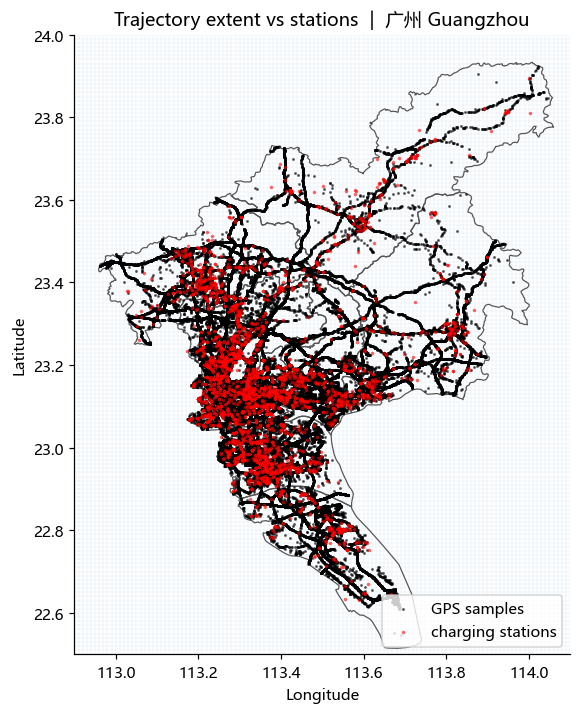

In [39]:
n_sample = min(rows, 80000) 
samp = (lf.select(['lon','lat']).filter(E.pl.col('lon').is_between(b['lon_min'],b['lon_max']) & E.pl.col('lat').is_between(b['lat_min'],b['lat_max']))
        .gather_every(max(1, rows//n_sample)).collect()) 
fig, ax = plt.subplots(figsize=(6.6,6.6))
E.draw_city_context(ax=ax, show_admin=True, show_grid=True, grid_alpha=0.18, grid_linewidth=0.25)
ax.scatter(samp['lon'], samp['lat'], s=1, c="#000000", alpha=0.5, label='GPS samples', zorder=4)
ax.scatter(st[sc['lon']], st[sc['lat']], s=2, c="#ff0000", alpha=0.6, marker='x', label='charging stations', zorder=5)
ax.set_title('Trajectory extent vs stations  |  %s' % cfg['label'])
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

城市名: 广州 | 市级 adcode: 440100 | GPS 行政区列: admin_code
城市: 广州 Guangzhou | 二级分区数: 11
行政区边界：按城市名 '广州' 解析为 440100，使用 admin_440100_full.geojson。 站点分区：GeoJSON 空间匹配。


,district_code,district_name,gps_records,vehicles,stations,fast_guns,slow_guns,gps_share,station_share,station_per_10k_gps,share_gap_station_minus_gps
0,440113,番禺区,2363287,11416,592,8562,935,0.179082,0.186928,2.504986,0.007845
1,440111,白云区,2100439,13665,607,10498,2219,0.159165,0.191664,2.889872,0.032499
2,440112,黄埔区,2075673,11851,272,3531,852,0.157288,0.085886,1.310418,-0.071402
3,440118,增城区,1400223,8634,246,2652,434,0.106105,0.077676,1.756863,-0.028428
4,440114,花都区,1400157,9587,324,3539,604,0.106100,0.102305,2.314026,-0.003794
5,440106,天河区,1077012,9394,368,5336,1101,0.081613,0.116198,3.416861,0.034586
6,440115,南沙区,904284,6307,180,1892,305,0.068524,0.056836,1.990525,-0.011688
7,440105,海珠区,694301,6760,196,3548,487,0.052612,0.061888,2.822983,0.009276
8,440117,从化区,548740,3637,161,925,464,0.041582,0.050837,2.933994,0.009255
9,440103,荔湾区,346471,5395,121,1672,248,0.026254,0.038207,3.492356,0.011952


,metric,total,mean_per_district,cv,gini
0,GPS records,13196639,1.199694e+06,0.581706,0.329155
1,stations,3167,2.879091e+02,0.576825,0.310245


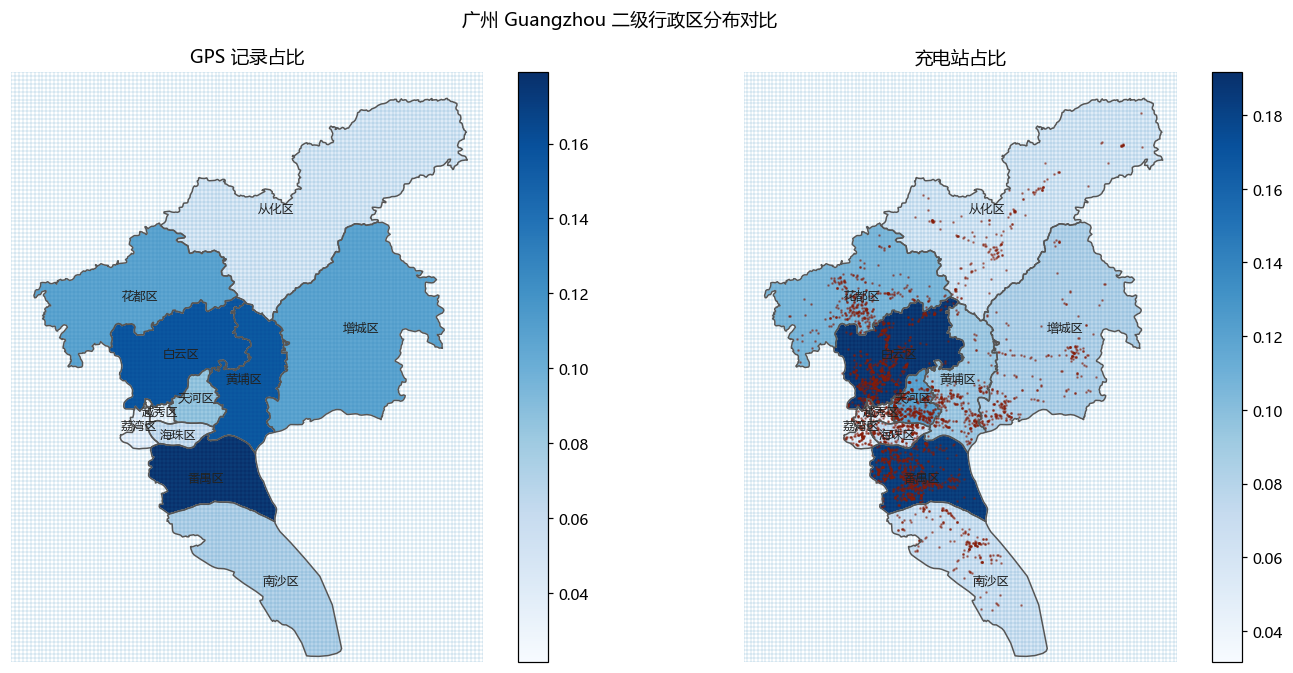

In [ ]:
# 读取对应城市的二级分区，然后统计不同分区内的 GPS 记录数和站点数，看看分布是否均匀。
from IPython.display import display

district = E.district_distribution(lf, rows=rows)
dist = district['dist']
uniformity = district['uniformity']
map_gdf = district['map_gdf']
station_gdf = district['station_gdf']

print(f"城市名: {district['city_name']} | 市级 adcode: {district['city_adcode']} | GPS 行政区列: {district['admin_col']}")
print(f"城市: {cfg['label']} | 二级分区数: {len(dist)}")
print(district['boundary_note'])
display(dist[[
    'district_code', 'district_name', 'gps_records', 'vehicles', 'stations',
    'fast_guns', 'slow_guns', 'gps_share', 'station_share',
    'station_per_10k_gps', 'share_gap_station_minus_gps'
]])
display(uniformity)

fig, axes = plt.subplots(1, 2, figsize=(13, 6.2))
maps = [
    ('gps_share', 'GPS 记录占比', 'Blues'),
    ('station_share', '充电站占比', 'Blues'),
]
for ax, (col, title, cmap) in zip(axes, maps):
    map_gdf.plot(
        column=col, cmap=cmap, linewidth=0.8, edgecolor='white',
        legend=True, ax=ax, missing_kwds={'color': '#f0f0f0', 'label': '无数据'},
    )
    E.draw_city_context(
        ax=ax, admin_gdf=map_gdf, show_admin=True, show_grid=True, show_labels=True,
        boundary_linewidth=1.0, grid_linewidth=0.3, grid_alpha=0.4,
        xlabel=None, ylabel=None,
    )
    ax.set_title(title)
    ax.set_axis_off()
station_gdf.plot(ax=axes[1], color='#851B08', markersize=0.5, alpha=0.5)
axes[1].set_title('充电站占比')
plt.suptitle(f"{cfg['label']} 二级行政区分布对比", y=0.98)
plt.tight_layout(); plt.show()

## 1.4 每辆车的 GPS 点数分布(数据量异质性)

每车点数: 中位 246, 均值 395, 最大 17936


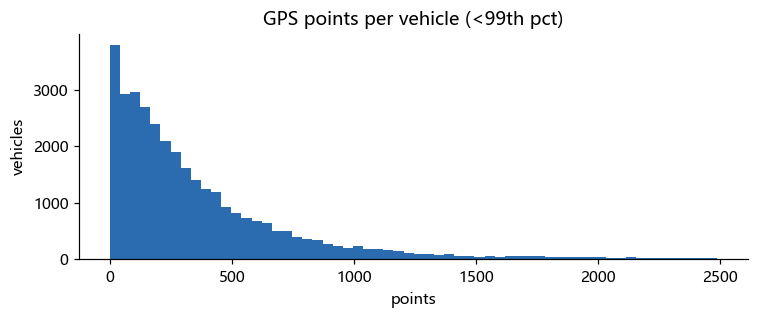

In [34]:
cnt = (lf.group_by('vehicle_id').agg(E.pl.len().alias('n')).collect()['n'].to_numpy())
print('每车点数: 中位 %d, 均值 %.0f, 最大 %d' % (np.median(cnt), cnt.mean(), cnt.max()))
plt.figure(figsize=(7,3)); plt.hist(cnt[cnt<np.percentile(cnt,99)], bins=60, color='#2b6cb0')
plt.title('GPS points per vehicle (<99th pct)'); plt.xlabel('points'); plt.ylabel('vehicles'); plt.tight_layout(); plt.show()

## 1.5 速度分布

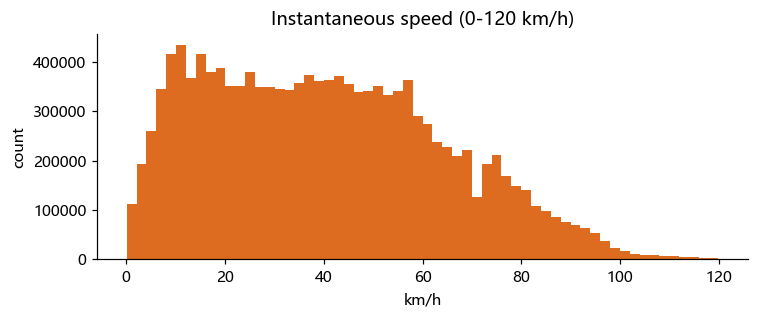

速度: 中位 38.9, 均值 40.4 km/h


In [35]:
spd = lf.select('speed_kmh').collect()['speed_kmh'].to_numpy()
spd = spd[(spd>0) & (spd<120)]
plt.figure(figsize=(7,3)); plt.hist(spd, bins=60, color='#dd6b20')
plt.title('Instantaneous speed (0-120 km/h)'); plt.xlabel('km/h'); plt.ylabel('count'); plt.tight_layout(); plt.show()
print('速度: 中位 %.1f, 均值 %.1f km/h' % (np.median(spd), spd.mean()))